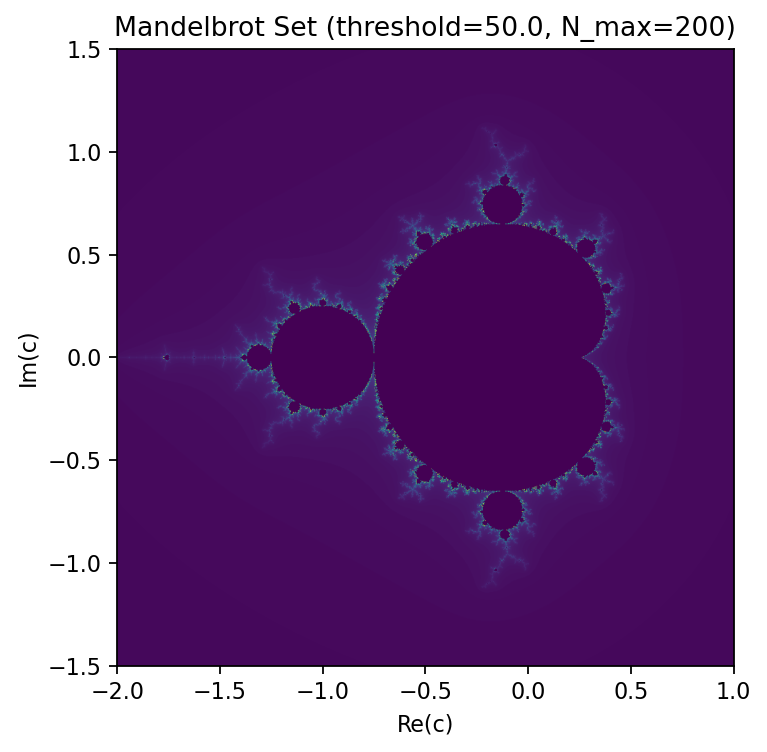

In [1]:
# Mandelbrot set 
# iteration: z_{n+1} = z_n^2 + c, z0=0
# region: [-2, 1] x [-1.5, 1.5]；threshold: 50；vectorized

import numpy as np
import matplotlib.pyplot as plt

# parameter 
xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5
nx, ny = 1000, 1000           # grid resolution
escape_threshold = 50.0       # threshold
N_max = 200                   # maximum number of iterations

# creat the complex plane grid  
x = np.linspace(xmin, xmax, nx) # evenly spaced real values
y = np.linspace(ymin, ymax, ny) # evenly spaced imaginary values
X, Y = np.meshgrid(x, y)      # shape: (ny, nx)
c = X + 1j * Y                # combine into a complex grid c = x + i*y

# iteration(vectorized) 
z = np.zeros_like(c, dtype=np.complex128)
escaped = np.zeros(c.shape, dtype=bool)         # record which pixels have escaped
iters = np.zeros(c.shape, dtype=np.int32)       # record the iteration in which the escape occurred

thr2 = escape_threshold * escape_threshold
big_cap = 1e100  # avoid extreme floating-point overflow

for n in range(1, N_max + 1):
    # only update active points: those not yet escaped and not too large
    active = (~escaped) & (np.abs(z) < big_cap)
    z[active] = z[active]*z[active] + c[active]

    # compute squared magnitude |z|^2 and check which points just exceeded the threshold
    mag2 = z.real*z.real + z.imag*z.imag
    just_escaped = (~escaped) & (mag2 > thr2)
    
 # record the iteration count for points that just escaped
    iters[just_escaped] = n
    escaped |= just_escaped

# points that never escaped within N_max iterations are considered inside the set
mandelbrot_mask = ~escaped

# plot the fractal
fig, ax = plt.subplots(dpi=160)
# show the number of iterations at escape; darker = slower to escape
im = ax.imshow(iters, extent=[xmin, xmax, ymin, ymax], origin='lower')
ax.set_xlabel("Re(c)")
ax.set_ylabel("Im(c)")
ax.set_title(f"Mandelbrot Set (threshold={escape_threshold}, N_max={N_max})")
plt.tight_layout()
plt.savefig("mandelbrot.png", bbox_inches="tight")
plt.show()




In [9]:
import numpy as np

# fix random seed for reproducibility 
np.random.seed(42)

n = 5  # number of states

# construct a random 5x5 matrix P and normalize each row so that sum_j P_ij = 1
P = np.random.rand(n, n)
P = P / P.sum(axis=1, keepdims=True)    # normalize each row
assert np.allclose(P.sum(axis=1), 1.0), "each row must sum to 1"

# construct a random size-5 vector p and normalize it so that sum_j p_j = 1
p = np.random.rand(n)
p = p / p.sum()
assert np.isclose(p.sum(), 1.0), "p must be a probability vector"

# apply the transition rule 50 times: p_{k+1} = P^T * p_k
for _ in range(50):
    p = np.dot(P.T, p)
p50 = p.copy()
assert np.isclose(p50.sum(), 1.0), "p50 must remain a probability distribution"

# compute the eigenvector v of P^T corresponding to eigenvalue 1 
# then normalize it so that sum_j v_j = 1 
w, V = np.linalg.eig(P.T)          # eigenvalues and eigenvectors of P^T
idx = np.argmin(np.abs(w - 1.0))   # find eigenvalue closest to 1
v = np.real_if_close(V[:, idx])    # remove small imaginary parts
v = np.maximum(v, 0.0)             # ensure non-negative entries
if v.sum() == 0:
    v = np.abs(V[:, idx].real)
stationary = v / v.sum()           # normalize to sum to 1

# compute the component-wise difference between p50 and stationary distribution
diff = np.abs(p50 - stationary)
l1_err = np.sum(diff)
linf_err = np.max(diff)
within = np.all(diff < 1e-5)

# print results 
np.set_printoptions(precision=6, suppress=True)
print("Transition matrix P (row-stochastic):\n", P)
print("\nInitial distribution p0 (only showing final result after 50 steps):")
print("\nDistribution after 50 steps (p50):\n", p50)
print("\nStationary distribution (eigenvector of P^T at λ ≈ 1):\n", stationary)
print("\nComponent-wise absolute difference |p50 - stationary|:\n", diff)
print(f"\nL1 error = {l1_err:.6e},  L∞ error = {linf_err:.6e}")
print("\nDo they match within 1e-5 component-wise? ->", within)


Transition matrix P (row-stochastic):
 [[0.133197 0.338101 0.260318 0.2129   0.055485]
 [0.065285 0.024308 0.362501 0.251571 0.296334]
 [0.009284 0.437468 0.375464 0.095773 0.08201 ]
 [0.105673 0.175297 0.302353 0.248877 0.1678  ]
 [0.327909 0.074759 0.156568 0.196343 0.244421]]

Initial distribution p0 (only showing final result after 50 steps):

Distribution after 50 steps (p50):
 [0.107852 0.222984 0.308894 0.189324 0.170945]

Stationary distribution (eigenvector of P^T at λ ≈ 1):
 [0.107852 0.222984 0.308894 0.189324 0.170945]

Component-wise absolute difference |p50 - stationary|:
 [0. 0. 0. 0. 0.]

L1 error = 2.248202e-15,  L∞ error = 6.106227e-16

Do they match within 1e-5 component-wise? -> True


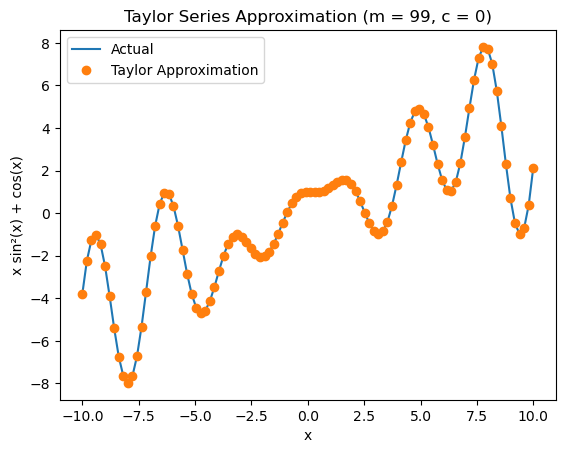

   degree      L1_error  time_seconds
0      50  4.949573e+01      0.372050
1      60  1.754248e-03      0.451687
2      70  1.319990e-07      0.563848
3      80  1.394495e-07      0.658369
4      90  1.394495e-07      0.791003
CSV saved to: taylor_values.csv


In [17]:
# Taylor Series Approximation 

import math
import time
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

# Task 1: Write a function that takes five inputs (a–e)
def taylor_series_approx(func_expr, start, end, degree, fixed_c, n_points=100):
  #  """
  #  Task 1(a) func:     the function to approximate
   # Task 1(b) start:    beginning of interval
  #  Task 1(c) end:      end of interval
   # Task 1(d) degree:   highest term m in Eq. (3.2)
   # Task 1(e) fixed_c:  expansion point c in Eq. (3.2)

  #  EN: Compute truncated Taylor polynomial of func_expr about x=fixed_c up to degree.
    
   # """
    x = sp.symbols('x')

    # build P_m(x) = Σ_{n=0}^{degree} f⁽ⁿ⁾(c)/n!·(x−c)ⁿ
    series_sum = 0
    for n in range(degree + 1):
        deriv = sp.diff(func_expr, x, n)
        deriv_at_c = deriv.subs(x, fixed_c)
        term = deriv_at_c * (x - fixed_c)**n / math.factorial(n)
        series_sum += term
    approx_expr = sp.simplify(series_sum)

    # convert to numeric functions
    f_num = sp.lambdify(x, func_expr, 'numpy')
    p_num = sp.lambdify(x, approx_expr, 'numpy')

    # evaluate on grid [start, end]
    xs = np.linspace(start, end, n_points)
    f_vals = f_num(xs)
    approx_vals = p_num(xs)
    return xs, f_vals, approx_vals, approx_expr


# Task 2: run the above function using given parameters
x = sp.symbols('x')

# Task 2(a) f(x) = x·sin²x + cos x
f_expr = x * sp.sin(x)**2 + sp.cos(x)

# Task 2(b) domain [–10, 10] with 100 points
domain_start, domain_end = -10, 10
num_points = 100

# Task 2(c) use 100 terms ⇒ m = 99
m = 99

# Task 2(d) expand about c = 0
c0 = 0

# run the approximation function
xs, f_true, f_hat, poly_expr = taylor_series_approx(
    f_expr, domain_start, domain_end, m, c0, n_points=num_points
)

# plot true function vs. Taylor approximation
plt.figure()
plt.plot(xs, f_true, label='Actual')
plt.plot(xs, f_hat, 'o', label='Taylor Approximation')
plt.xlabel('x')
plt.ylabel('x sin²(x) + cos(x)')
plt.legend()
plt.title('Taylor Series Approximation (m = 99, c = 0)')
plt.show()

# factorial sweep for multiple degrees save CSV
def taylor_factorial_sweep(func_expr, start, end, fixed_c,
                           initial_degree, final_degree, degree_step,
                           n_points=100, csv_path='taylor_values.csv'):
    """
     Run Taylor approximation for m from initial→final by step degree_step,
        record L1 error Σ|f(xᵢ)−Pₘ(xᵢ)| and runtime.
    
    """
    degrees = list(range(initial_degree, final_degree + 1, degree_step))
    rows = []
# create a list of all degrees m to test
    for m in degrees: # loop over all cutoff degrees m
        t0 = time.perf_counter() # record the start time for timing the computation
        xs, f_vals, approx_vals, _ = taylor_series_approx(
            func_expr, start, end, m, fixed_c, n_points=n_points
        ) #  call the Taylor approximation function to compute true and approximate values
        t1 = time.perf_counter()
        l1_error = float(np.sum(np.abs(f_vals - approx_vals)))
        rows.append({'degree': m, 'L1_error': l1_error, 'time_seconds': t1 - t0})

    df = pd.DataFrame(rows, columns=['degree', 'L1_error', 'time_seconds'])
    df.to_csv(csv_path, index=False) # convert the list of dictionaries to a Pandas DataFrame
    return df, csv_path # return both the DataFrame and the CSV path


# example sweep :run the factorial sweep function for m = 50, 20, 30, …, 100.
#  It computes L1 error and runtime for each degree, then saves results to 'taylor_values.csv'.
df_results, csv_path = taylor_factorial_sweep(
    f_expr,
    domain_start, domain_end,
    c0,
    initial_degree=50,
    final_degree=100,
    degree_step=10,
    n_points=num_points,
    csv_path='taylor_values.csv'
)

print(df_results.head())
print(f"CSV saved to: {csv_path}")
